In [147]:
import numpy as np
import scipy.special



In [148]:
def modmc1(m, q, x):
    return scipy.special.mathieu_modcem1(m, q, x)
def modmc2(m, q, x):
    return scipy.special.mathieu_modcem2(m, q, x)

def modms1(m, q, x):
    return scipy.special.mathieu_modsem1(m, q, x)
def modms2(m, q, x):
    return scipy.special.mathieu_modsem2(m, q, x)

def mathieu_a(m, q):
    return scipy.special.mathieu_a(m, q)

def mathieu_b(m, q):
    return scipy.special.mathieu_b(m, q)



In [149]:
# Round trip modmc1
NN = 100
v = np.linspace(2,5,NN)
h = 5e-6
tol = 1e-3
MM = 50
qs = np.logspace(-4,4,10)



error = []
idx = 1
for m in range(MM):
    for q in qs:
        fm3 = modmc1(m, q, v - 3 * h)[idx]
        fm2 = modmc1(m, q, v - 2 * h)[idx]
        fm1 = modmc1(m, q, v - h)[idx]
        fp1 = modmc1(m, q, v + h)[idx]
        fp2 = modmc1(m, q, v + 2 * h)[idx]
        fp3 = modmc1(m, q, v + 3 * h)[idx]

        ydd = -fm3/60 + 3*fm2/20 - 3*fm1/4 + 3*fp1/4 - 3*fp2/20 + fp3/60

        [y,yd] = modmc1(m,q,v)
        a = mathieu_a(m,q)

        r = ydd/(h) - (a - 2 * q * np.cosh(2*v)) * y
        stddev = np.std(r)
        l2norm = np.linalg.norm(y, ord=2) / np.sqrt(len(y))

        error.append( stddev/np.linalg.norm(y, ord=2))
        if not np.isclose( l2norm , 0, atol=tol):
            
            print(f'm = {m}, q = {q}, error = {l2norm}')




m = 0, q = 0.0001, error = 0.9208188940744474
m = 0, q = 0.000774263682681127, error = 0.7377963501464324
m = 0, q = 0.005994842503189409, error = 0.49405494060468
m = 0, q = 0.046415888336127774, error = 0.22163277040139695
m = 0, q = 0.3593813663804626, error = 0.14626195563846783
m = 0, q = 2.782559402207126, error = 0.09023611530244158
m = 0, q = 21.54434690031882, error = 0.05363236321490723
m = 0, q = 166.81005372000558, error = 0.029641225309170176
m = 0, q = 1291.5496650148827, error = 0.020873216131661692
m = 0, q = 10000.0, error = nan
m = 1, q = 0.0001, error = 0.26589383464254734
m = 1, q = 0.000774263682681127, error = 0.3700716544738418
m = 1, q = 0.005994842503189409, error = 0.37953293676308947
m = 1, q = 0.046415888336127774, error = 0.2951749199146213
m = 1, q = 0.3593813663804626, error = 0.1590347192646567
m = 1, q = 2.782559402207126, error = 0.09048639242214815
m = 1, q = 21.54434690031882, error = 0.0550102758516955
m = 1, q = 166.81005372000558, error = 0.034149

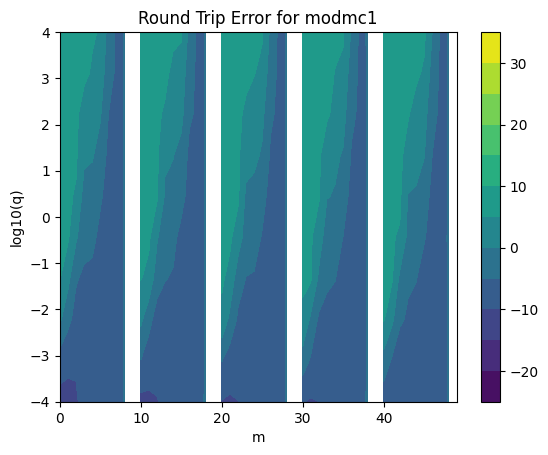

In [150]:
import matplotlib.pyplot as plt

from matplotlib.colors import Normalize


M, Q = np.meshgrid(range(MM), qs)

error_array = np.array(error).reshape(M.shape)


levels = np.arange(-25, 36, 5)

plt.contourf(M, np.log10(Q), np.log10(error_array), levels=levels, cmap='viridis')
plt.colorbar()

plt.xlabel("m")
plt.ylabel("log10(q)")
plt.title("Round Trip Error for modmc1")

plt.show()

In [151]:
# Round trip modmc2

NN = 100
v = np.linspace(2,5,NN)
h = 1e-5
tol = 1e-3
MM = 50
qs = np.logspace(-4,4,10)
error = []
for m in range(MM):
    for q in qs:
        fm3 = modmc2(m, q, v - 3 * h)[1]
        fm2 = modmc2(m, q, v - 2 * h)[1]
        fm1 = modmc2(m, q, v - h)[1]
        fp1 = modmc2(m, q, v + h)[1]
        fp2 = modmc2(m, q, v + 2 * h)[1]
        fp3 = modmc2(m, q, v + 3 * h)[1]

        ydd = -fm3/60 + 3*fm2/20 - 3*fm1/4 + 3*fp1/4 - 3*fp2/20 + fp3/60

        [y,yd] = modmc2(m,q,v)
        a = mathieu_a(m,q)

        r = ydd/(h) - (a - 2 * q * np.cosh(2*v)) * y
        stddev = np.std(r)
        l2norm = np.linalg.norm(y, ord=2) / np.sqrt(len(y))

        error.append( stddev/np.linalg.norm(y, ord=2))
        if not np.isclose( l2norm , 0, atol=tol):
            print(f'm = {m}, q = {q}, error = {l2norm}')



m = 0, q = 0.0001, error = 0.9420240036876363
m = 0, q = 0.000774263682681127, error = 0.5118103471208666
m = 0, q = 0.005994842503189409, error = 0.29723173588757607
m = 0, q = 0.046415888336127774, error = 0.2767478077400959
m = 0, q = 0.3593813663804626, error = 0.15589650185033507
m = 0, q = 2.782559402207126, error = 0.0909470767834755
m = 0, q = 21.54434690031882, error = 0.05487262454524635
m = 0, q = 166.81005372000558, error = 0.03514940344919177
m = 0, q = 1291.5496650148827, error = 0.017995391711820685
m = 0, q = 10000.0, error = nan
m = 1, q = 0.0001, error = 3.6455303386217524
m = 1, q = 0.000774263682681127, error = 1.3957746388219412
m = 1, q = 0.005994842503189409, error = 0.5511523960070354
m = 1, q = 0.046415888336127774, error = 0.21610356377599033
m = 1, q = 0.3593813663804626, error = 0.14485092839233402
m = 1, q = 2.782559402207126, error = 0.09123725613674576
m = 1, q = 21.54434690031882, error = 0.053636429828990896
m = 1, q = 166.81005372000558, error = 0.0308

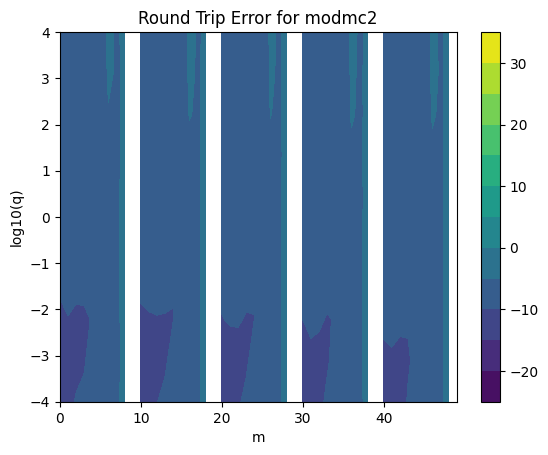

In [152]:
import matplotlib.pyplot as plt

M, Q = np.meshgrid(range(MM), qs)

error_array = np.array(error).reshape(M.shape)

levels = np.arange(-25, 36, 5)

plt.contourf(M, np.log10(Q), np.log10(error_array), levels=levels, cmap='viridis')
plt.colorbar()

plt.xlabel("m")
plt.ylabel("log10(q)")
plt.title("Round Trip Error for modmc2")

plt.show()
# fig, ax = plt.subplots()
# im = ax.pcolormesh(range(MM), np.log10(qs), np.log10(error_array), cmap='viridis')

# cbar = fig.colorbar(im, ax=ax)
# cbar.set_label('Value')

# ax.set_title("Round Trip Error for modmc2")
# ax.set_xlabel("m")
# ax.set_ylabel("log10(q)")

# plt.show()

In [153]:
import math
# Round trip modms1

NN = 100
v = np.linspace(2,5,NN)
h = 1e-5
tol = 1e-3
MM = 100
qs = np.logspace(-4,2,10)
error = []

for m in range(1, MM):
    for q in qs:
        fm3 = modms1(m, q, v - 3 * h)[1]
        fm2 = modms1(m, q, v - 2 * h)[1]
        fm1 = modms1(m, q, v - h)[1]
        fp1 = modms1(m, q, v + h)[1]
        fp2 = modms1(m, q, v + 2 * h)[1]
        fp3 = modms1(m, q, v + 3 * h)[1]

        ydd = -fm3/60 + 3*fm2/20 - 3*fm1/4 + 3*fp1/4 - 3*fp2/20 + fp3/60

        [y,yd] = modms1(m,q,v)
        a = mathieu_b(m,q)

        r = ydd/(h) - (a - 2 * q * np.cosh(2*v)) * y
        stddev = np.std(r)
        l2norm = np.linalg.norm(y, ord=2) 

        
        error.append(stddev / l2norm)
        if not np.isclose( stddev/ l2norm , 0, atol=tol):
            print(f'm = {m}, q = {q}, error = {l2norm}')



m = 6, q = 0.0001, error = 0.00038195381580700684
m = 8, q = 0.0001, error = 1.646727036295989e-05
m = 8, q = 0.00046415888336127773, error = 0.0013182501639722945
m = 9, q = 0.0001, error = 2.755584366110699e-07
m = 10, q = 0.0001, error = 7.624720809402724e-06
m = 10, q = 0.00046415888336127773, error = 4.0760441456400565e-05
m = 11, q = 0.0001, error = 1.2922740591430605e-09
m = 11, q = 0.00046415888336127773, error = 5.118393025101472e-06
m = 12, q = 0.0001, error = 0.00047653711920764665
m = 12, q = 0.00046415888336127773, error = 0.0001353973254374459
m = 12, q = 0.002154434690031882, error = 0.003344155668822158
m = 13, q = 0.0001, error = 4.275052046704242e-12
m = 13, q = 0.00046415888336127773, error = 8.138952642796245e-08
m = 14, q = 0.0001, error = 0.0011565279946569678
m = 14, q = 0.00046415888336127773, error = 0.0006285718356270361
m = 14, q = 0.002154434690031882, error = 0.00020863868015635464
m = 15, q = 0.0001, error = 1.2207886318741463e-12
m = 15, q = 0.00046415888

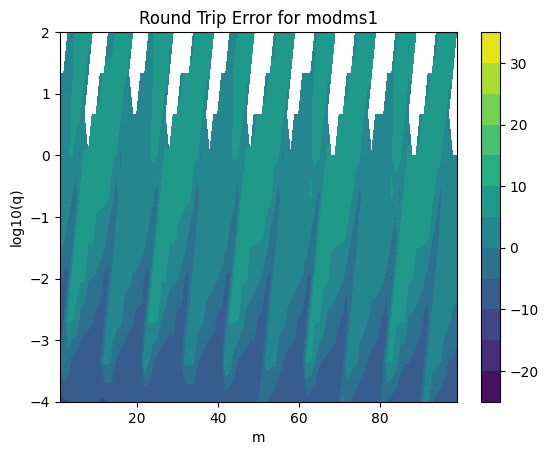

In [154]:
import matplotlib.pyplot as plt

M, Q = np.meshgrid(range(1,MM), qs)

error_array = np.array(error).reshape(M.shape)


levels = np.arange(-25, 36, 5)

plt.contourf(M, np.log10(Q), np.log10(error_array), levels=levels, cmap='viridis')
plt.colorbar()

plt.xlabel("m")
plt.ylabel("log10(q)")
plt.title("Round Trip Error for modms1")
# fig, ax = plt.subplots()
# im = ax.pcolormesh(range(1, MM), np.log10(qs), error_array, cmap='viridis')

# cbar = fig.colorbar(im, ax=ax)
# cbar.set_label('Value')

# ax.set_title("Round Trip Error for modsm1")
# ax.set_xlabel("m")
# ax.set_ylabel("log10(q)")

plt.show()

In [155]:
# Round trip modms2

NN = 100
v = np.linspace(2,5,NN)
h = 1e-5
tol = 1e-3
MM = 100
qs = np.logspace(-4,2,10)
error = []

for m in range(1, MM):
    for q in qs:
        fm3 = modms2(m, q, v - 3 * h)[1]
        fm2 = modms2(m, q, v - 2 * h)[1]
        fm1 = modms2(m, q, v - h)[1]
        fp1 = modms2(m, q, v + h)[1]
        fp2 = modms2(m, q, v + 2 * h)[1]
        fp3 = modms2(m, q, v + 3 * h)[1]

        ydd = -fm3/60 + 3*fm2/20 - 3*fm1/4 + 3*fp1/4 - 3*fp2/20 + fp3/60

        [y,yd] = modms2(m,q,v)
        a = mathieu_b(m,q)

        r = ydd/(h) - (a - 2 * q * np.cosh(2*v)) * y
        stddev = np.std(r)
        l2norm = np.linalg.norm(y, ord=2) 
        error.append( stddev / l2norm)

        if not np.isclose(stddev / l2norm , 0, atol=tol):
            print(f'm = {m}, q = {q}, error = { l2norm}')



m = 57, q = 100.0, error = 0.37716585466446817
m = 58, q = 0.0001, error = inf
m = 58, q = 100.0, error = 0.41533788992541043
m = 59, q = 0.0001, error = inf
m = 59, q = 100.0, error = 0.39349204389244535
m = 60, q = 0.0001, error = inf
m = 60, q = 100.0, error = 0.40156821593435854
m = 61, q = 0.0001, error = inf
m = 61, q = 100.0, error = 0.4117291965531259
m = 62, q = 0.0001, error = inf
m = 62, q = 100.0, error = 0.4188003779738571
m = 63, q = 0.0001, error = inf
m = 63, q = 100.0, error = 0.3833938674133843
m = 64, q = 0.0001, error = inf
m = 64, q = 100.0, error = 0.4135836651242532
m = 65, q = 0.0001, error = inf
m = 65, q = 100.0, error = 0.4299041274547322
m = 66, q = 0.0001, error = inf
m = 66, q = 0.00046415888336127773, error = inf
m = 66, q = 100.0, error = 0.39363666647435297
m = 67, q = 0.0001, error = inf
m = 67, q = 0.00046415888336127773, error = inf
m = 67, q = 100.0, error = 0.443743220374162
m = 68, q = 0.0001, error = inf
m = 68, q = 0.00046415888336127773, error 

/Users/aliamy/Desktop/Mathieu/mathieu/lib/python3.13/site-packages/numpy/linalg/_linalg.py:2791: RuntimeWarning: overflow encountered in dot
  sqnorm = x.dot(x)
/Users/aliamy/Desktop/Mathieu/mathieu/lib/python3.13/site-packages/numpy/_core/_methods.py:193: RuntimeWarning: overflow encountered in multiply
  x = um.multiply(x, x, out=x)
/var/folders/wt/zm67l5653nz4gjnqr_vxcvnc0000gn/T/ipykernel_15000/3235430101.py:28: RuntimeWarning: invalid value encountered in scalar divide
  error.append( stddev / l2norm)
/var/folders/wt/zm67l5653nz4gjnqr_vxcvnc0000gn/T/ipykernel_15000/3235430101.py:30: RuntimeWarning: invalid value encountered in scalar divide
  if not np.isclose(stddev / l2norm , 0, atol=tol):
/Users/aliamy/Desktop/Mathieu/mathieu/lib/python3.13/site-packages/numpy/_core/_methods.py:204: RuntimeWarning: overflow encountered in reduce
  ret = umr_sum(x, axis, dtype, out, keepdims=keepdims, where=where)


/var/folders/wt/zm67l5653nz4gjnqr_vxcvnc0000gn/T/ipykernel_15000/532943979.py:9: RuntimeWarning: divide by zero encountered in log10
  plt.contourf(M, np.log10(Q), np.log10(error_array), levels=levels, cmap='viridis')


Text(0.5, 1.0, 'Round Trip Error for modms2')

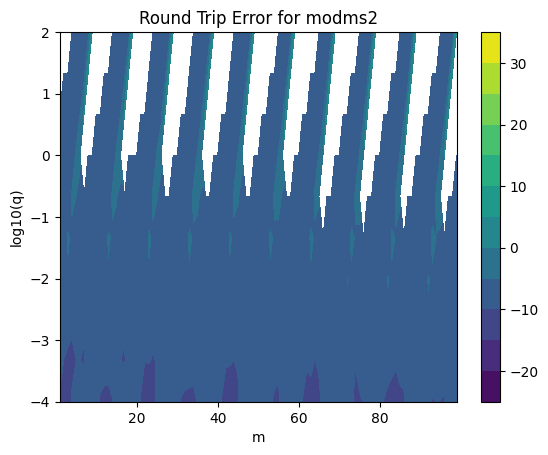

In [156]:
import matplotlib.pyplot as plt

M, Q = np.meshgrid(range(1,MM), qs)

error_array = np.array(error).reshape(M.shape)

levels = np.arange(-25, 36, 5)

plt.contourf(M, np.log10(Q), np.log10(error_array), levels=levels, cmap='viridis')
plt.colorbar()

plt.xlabel("m")
plt.ylabel("log10(q)")
plt.title("Round Trip Error for modms2")
# fig, ax = plt.subplots()
# im = ax.pcolormesh(range(1, MM), np.log10(qs), error_array, cmap='viridis')

# cbar = fig.colorbar(im, ax=ax)
# cbar.set_label('Value')

# ax.set_title(" Round Trip Error for modsm2")
# ax.set_xlabel("m")
# ax.set_ylabel("log10(q)")

# plt.show()